### Practical Work
Dataset: GB1 Data


In [1]:
# Imports
import pandas as pd
import numpy as np
import tensorflow as tf

from sklearn.model_selection import train_test_split
from split.create_split import create_split

import mavenn
import torch

from models import mlp_oracle
from models.random_forest import RandomForestPredictor
from models.single_mutant_walker import SMW
from main_scorer import plot_results, mutate_score_sequence_GB1

import matplotlib.pyplot as plt

SEED = 42
AA_List = ['A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'V', 'W', 'Y']

2026-02-18 15:43:29.382593: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# Helper methods to one-hot-encode sequences
# One hot encode the sequences
AMINO_ACIDS = 'ACDEFGHIKLMNPQRSTVWY'
vocab_size = len(AMINO_ACIDS)  # 20 amino acids
aa_to_idx = {aa: i for i, aa in enumerate(AMINO_ACIDS)}

def sequences_to_indices(sequences):
    """Convert sequences of amino acids to sequences of indices."""
    return [aa_to_idx.get(aa, 0) for aa in sequences]

def one_hot(sequences, vocab_size):
    """One-hot encode sequences (2D array of indices)."""
    one_hot = np.zeros((sequences.shape[0], sequences.shape[1], vocab_size), dtype=np.float32)
    for i in range(sequences.shape[0]):
        for j in range(sequences.shape[1]):
            aa_index = sequences[i, j]
            if aa_index < vocab_size:
                one_hot[i, j, aa_index] = 1.0
    return one_hot

def one_hot_encode(sequence) -> np.ndarray:
        """One-hot encode a sequence and flatten it.

        Args:
            sequence: List of nucleotide indices.

        Returns:
            Flattened one-hot encoded sequence of shape (1, seq_len * n).
        """
        sequence_tensor = tf.one_hot(sequence, depth=20)
        sequence_numpy = sequence_tensor.numpy()
        shape = sequence_numpy.shape[0] * sequence_numpy.shape[1]
        sequence_n_flat = sequence_numpy.reshape(1, shape)
        return sequence_n_flat

In [14]:
# Load dataset: GFP
df = mavenn.load_example_dataset('gb1')
df = df[['y', 'x']]
df.columns = ['binding_scores', 'sequence']
df['split'] = ['None'] * len(df)
print("data_loaded with shape:", df.shape)

df['split'] = ['None'] * len(df)

# Sequences to indices
df['encoded_sequence'] = df['sequence'].apply(sequences_to_indices)

df.head()



data_loaded with shape: (530737, 3)


,binding_scores,sequence,split,encoded_sequence
0,-3.145154,AAKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEWTYDD...,None,"[0, 0, 8, 9, 7, 9, 11, 5, 8, 16, 9, 8, 5, 3, 1..."
1,-1.867676,ACKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEWTYDD...,None,"[0, 1, 8, 9, 7, 9, 11, 5, 8, 16, 9, 8, 5, 3, 1..."
2,-5.270800,ADKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEWTYDD...,None,"[0, 2, 8, 9, 7, 9, 11, 5, 8, 16, 9, 8, 5, 3, 1..."
3,-5.979498,AEKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEWTYDD...,None,"[0, 3, 8, 9, 7, 9, 11, 5, 8, 16, 9, 8, 5, 3, 1..."
4,0.481923,AFKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEWTYDD...,None,"[0, 4, 8, 9, 7, 9, 11, 5, 8, 16, 9, 8, 5, 3, 1..."


Created Splits with Create Split method: 

df = create_split(df,
                  train_fraction=0.7,
                  k_seeds=50,
                  n_training_seeds=10,
                  fitness_percentile_cutoff=30.0,
                  training_radius_percentile=70.0,
                  random_state=SEED)

Next cell loads the already created spit dataset:

In [15]:
df = create_split(df,
                  train_fraction=0.7,
                  k_seeds=50,
                  n_training_seeds=10,
                  fitness_percentile_cutoff=30.0,
                  training_radius_percentile=70.0,
                  random_state=SEED)

In [16]:
train_df = df[df['split'] == 'train']

# print stats about train split
print("Train split stats:")
print(train_df['binding_scores'].describe())

x = np.array(train_df['encoded_sequence'].tolist())
print('Shape of x:', x.shape)
print('First row of x:', x[0])
y = train_df['binding_scores'].values

X_train, X_val, y_train, y_val = train_test_split(x, y, test_size=0.1, random_state=SEED)
# One hot encoding
X_train_onehot = tf.one_hot(X_train, depth=20).numpy()
X_val_onehot = tf.one_hot(X_val, depth=20).numpy()

Train split stats:
count    14319.000000
mean        -7.304079
std          0.875420
min        -10.896890
25%         -7.918956
50%         -7.257279
75%         -6.597028
max         -5.819421
Name: binding_scores, dtype: float64
Shape of x: (14319, 55)
First row of x: [ 0 19  8  9  7  9 11  5  8 16  9  8  5  3 16 16 16  3  0 17  2  0  0 16
  0  3  8 17  4  8 13 19  0 11  2 11  5  5  2  5  3 18 16 19  2  2  0 16
  8 16  4 16 17 16  3]


Next cell creates a dataframe with binding scores and one hot encoded sequences for the lookup task. 

In [17]:
oracle = mlp_oracle.MLPOracle(input_size=1100, output_size=1)
oracle.load_model('models/oracle_mlp.pth')

print(X_val_onehot[0].flatten().shape)

sequence = torch.tensor(X_val_onehot[0].flatten(), dtype=torch.float32)  # Shape: (1, 1100)
prediction = oracle.inference(sequence)
print(f"Predicted binding score: {prediction.item():.4f}, True binding score: {y_val[0]:.4f}")

(1100,)
Predicted binding score: -6.7835, True binding score: -6.5121


In [9]:
#Best params: {'max_depth': None, 'max_features': 0.5, 'min_samples_leaf': 3, 'min_samples_split': 10, 'n_estimators': 500}
rf = RandomForestPredictor()
#rf.train_with_gridsearch(X_train, y_train, X_val, y_val)

rf.train(X_train_onehot.reshape(X_train_onehot.shape[0], -1), y_train, n_estimators=500, max_depth=None, max_features=0.5, min_samples_leaf=3, min_samples_split=10)
rf_predictions = rf.evaluate(X_val_onehot.reshape(X_val_onehot.shape[0], -1), y_val)


Training Random Forest model...
Training completed.
R2 Score: 0.11648727785882274
MSE: 0.65951019198144
Spearman Correlation: 0.46306721814965907


In [10]:
# Use indices (0-19) instead of letters for SMW
AA_Indices = list(range(20))  # [0, ..., 19]
smw = SMW(AA_Indices)

seed_sequence = df[df['split'] == 'train']['encoded_sequence'].iloc[0]  # Take the first training sequence as seed
score_seed = df[df['split'] == 'train']['binding_scores'].iloc[0]
print(f"Seed sequence: {seed_sequence}, Seed score: {score_seed}")

values = mutate_score_sequence_GB1(smw, rf, seed_sequence, score_seed, steps=100, num_mutations=100)

Seed sequence: [0, 19, 8, 9, 7, 9, 11, 5, 8, 16, 9, 8, 5, 3, 16, 16, 16, 3, 0, 17, 2, 0, 0, 16, 0, 3, 8, 17, 4, 8, 13, 19, 0, 11, 2, 11, 5, 5, 2, 5, 3, 18, 16, 19, 2, 2, 0, 16, 8, 16, 4, 16, 17, 16, 3], Seed score: -7.068896983315637
Step 2, Mutation 12: Predicted score: -7.0369
Step 9, Mutation 44: Predicted score: -7.0314
Step 9, Mutation 45: Predicted score: -7.0300
Step 9, Mutation 48: Predicted score: -6.9983
Step 11, Mutation 6: Predicted score: -6.9663
Step 11, Mutation 7: Predicted score: -6.9539
Step 11, Mutation 12: Predicted score: -6.9085
Step 11, Mutation 14: Predicted score: -6.8914
Step 76, Mutation 6: Predicted score: -6.8909
Step 76, Mutation 10: Predicted score: -6.8674
Step 76, Mutation 11: Predicted score: -6.8657
Step 76, Mutation 23: Predicted score: -6.8651


Spearman Correlation: 0.1259


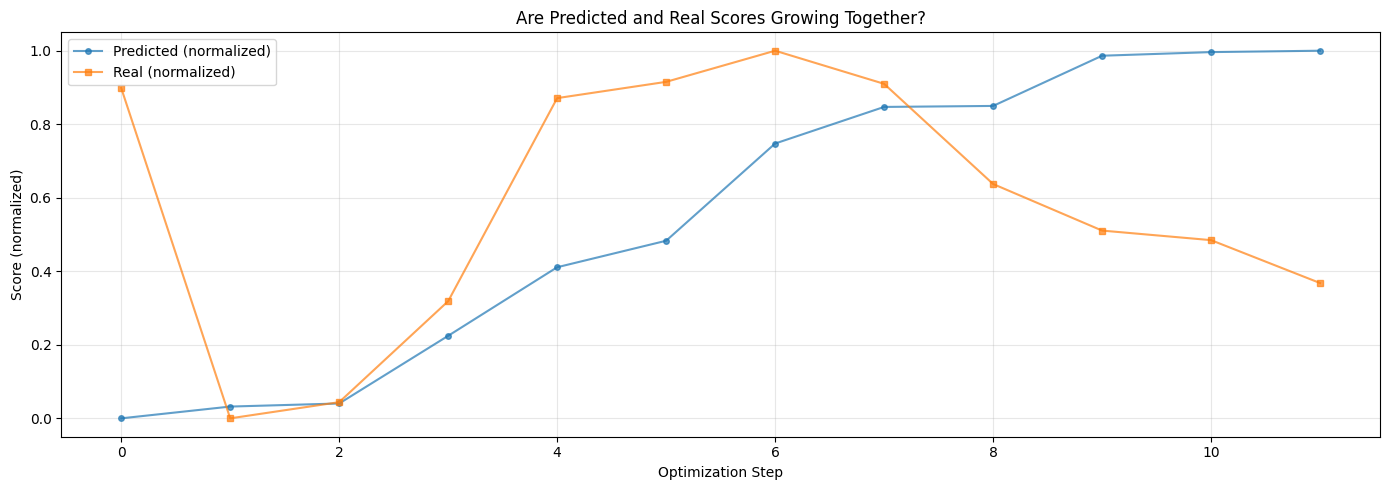

In [11]:
# Lookup real values for mutated sequences by oracle
values_df = pd.DataFrame(values)
values_df['real_score'] = values_df['mutation'].apply(lambda seq: oracle.inference(torch.tensor(seq, dtype=torch.float32)).item())
values_df['error'] = np.abs(values_df['real_score'] - values_df['predicted_score'])
plot_results(values_df)

### Mutate with SMW - Score with LSTM

In [28]:
from models.lstm import LSTMSequencePredictor, train, save_model,load_model


In [35]:
# Train LSTM Model on the training data
# Keep 3D shape for LSTM: (samples, timesteps, features)


lstm_model = LSTMSequencePredictor(input_size = 20)
train(lstm_model, X_train_onehot, y_train, X_val_onehot, y_val, epochs=50, batch_size=64)
save_model(lstm_model, 'lstm_scorer_GB1.pt')

Epoch 1/50 - loss: 13.7791 - val_loss: 1.3403
Epoch 2/50 - loss: 6.3397 - val_loss: 1.3273
Epoch 3/50 - loss: 6.1533 - val_loss: 1.1945
Epoch 4/50 - loss: 5.9546 - val_loss: 1.2651
Epoch 5/50 - loss: 5.7529 - val_loss: 1.0712
Epoch 6/50 - loss: 5.6877 - val_loss: 1.2236
Epoch 7/50 - loss: 5.4111 - val_loss: 1.2220
Epoch 8/50 - loss: 5.3352 - val_loss: 1.2261
Epoch 9/50 - loss: 5.1079 - val_loss: 1.1904
Epoch 10/50 - loss: 4.7695 - val_loss: 1.0179
Epoch 11/50 - loss: 4.6524 - val_loss: 1.1618
Epoch 12/50 - loss: 4.5236 - val_loss: 1.0961
Epoch 13/50 - loss: 4.3882 - val_loss: 1.1631
Epoch 14/50 - loss: 4.1311 - val_loss: 0.9341
Epoch 15/50 - loss: 4.0350 - val_loss: 0.9613
Epoch 16/50 - loss: 3.7905 - val_loss: 0.9774
Epoch 17/50 - loss: 3.5998 - val_loss: 1.0954
Epoch 18/50 - loss: 3.4680 - val_loss: 1.0341
Epoch 19/50 - loss: 3.3052 - val_loss: 0.8857
Epoch 20/50 - loss: 3.1210 - val_loss: 0.8931
Epoch 21/50 - loss: 2.8871 - val_loss: 0.8747
Epoch 22/50 - loss: 2.7511 - val_loss: 0.9

Seed sequence: [0, 19, 8, 9, 7, 9, 11, 5, 8, 16, 9, 8, 5, 3, 16, 16, 16, 3, 0, 17, 2, 0, 0, 16, 0, 3, 8, 17, 4, 8, 13, 19, 0, 11, 2, 11, 5, 5, 2, 5, 3, 18, 16, 19, 2, 2, 0, 16, 8, 16, 4, 16, 17, 16, 3], Seed score: -7.068896983315637
Step 1, Mutation 67: Predicted score: -7.0088
Step 1, Mutation 72: Predicted score: -7.0088
Step 1, Mutation 75: Predicted score: -7.0087
Step 1, Mutation 82: Predicted score: -7.0087
Step 1, Mutation 83: Predicted score: -7.0087
Step 1, Mutation 84: Predicted score: -7.0087
Step 12, Mutation 97: Predicted score: -6.9590
Step 12, Mutation 99: Predicted score: -6.9590
Step 17, Mutation 43: Predicted score: -6.9528
Step 17, Mutation 44: Predicted score: -6.9528
Step 17, Mutation 47: Predicted score: -6.9528
Step 17, Mutation 52: Predicted score: -6.9408
Step 17, Mutation 61: Predicted score: -6.9239
Step 34, Mutation 90: Predicted score: -6.8929
Step 34, Mutation 91: Predicted score: -6.8928
Step 34, Mutation 93: Predicted score: -6.8928
Step 37, Mutation 25

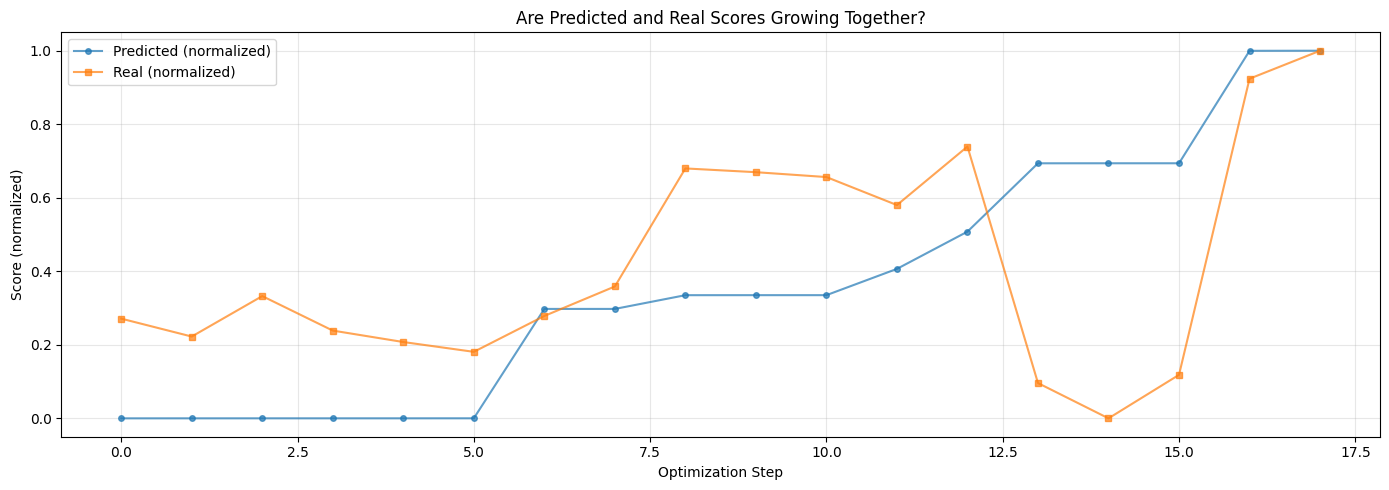

In [36]:

lstm_model = load_model('lstm_scorer_GB1.pt', input_size=20)


#Use indices (0-19) instead of letters for SMW
AA_Indices = list(range(20))  # [0, ..., 19]
smw = SMW(AA_Indices)

seed_sequence = df[df['split'] == 'train']['encoded_sequence'].iloc[0]  # Take the first training sequence as seed
score_seed = df[df['split'] == 'train']['binding_scores'].iloc[0]
print(f"Seed sequence: {seed_sequence}, Seed score: {score_seed}")


values = mutate_score_sequence_GB1(smw, lstm_model, seed_sequence, score_seed, steps=100, num_mutations=100)

values = pd.DataFrame(values)
values['real_score'] = values['mutation'].apply(lambda seq: oracle.inference(torch.tensor(seq, dtype=torch.float32)).item())
values['error'] = np.abs(values['real_score'] - values['predicted_score'])
plot_results(values)
